# Price Forecasting — Backtested Model Comparison

**Goal:** an actual predictive model for future commodity prices, evaluated honestly with **rolling-origin backtesting** (multiple train/test splits across time, not one lucky split) and standard error metrics (MAE, RMSE, MAPE).

**Design choice — weekly frequency:** the EDA/clustering/simulation notebooks worked at daily granularity. This notebook resamples to **weekly averages** for the forecasting models specifically, because:
- SARIMA's seasonal component becomes computationally intractable at a 365-day period on daily data; a 52-week period is tractable.
- Prophet and LightGBM both run considerably faster and produce less noisy forecasts on weekly data.
- Procurement/selling decisions (the actual business use case) rarely need day-level forecast precision anyway — a good weekly forecast is normally sufficient.

**Models compared:**
1. Naive seasonal baseline (this week's forecast = same week last year) — the floor. A model that can't beat this isn't adding value.
2. Moving average baseline — a second, simpler floor.
3. SARIMA (statsmodels) — classical, interpretable, good for strongly seasonal single series.
4. Prophet — handles trend changes and yearly seasonality with less manual tuning than SARIMA.
5. LightGBM — a **global** model trained across all commodities at once (lag + calendar + commodity-as-category features), so commodities with less individual history can borrow statistical strength from others.
6. LSTM (neuralforecast) — a recurrent neural net fit per commodity on the same weekly series as SARIMA/Prophet.
7. TFT (Temporal Fusion Transformer, neuralforecast) — an attention-based deep model; the most expressive candidate, at the cost of the most compute.

Each model is optional-dependency gated — if a library isn't installed, that section prints an install hint and is skipped rather than breaking the notebook.

**Choosing the final model:** the actual candidate pool for the "model we'd deploy" is restricted to `{SARIMA, Prophet, LSTM, TFT}` — the two baselines exist only as a bar to clear, and LightGBM is kept as a reference point but isn't a candidate. Section 11 explicitly checks that the chosen candidate beats the stronger of the two baselines before calling it final, and says so plainly if it doesn't.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import logging
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning").setLevel(logging.ERROR)
logging.getLogger("lightning.pytorch").setLevel(logging.ERROR)

sns.set_style("whitegrid")
%matplotlib inline
np.random.seed(42)

# ---- CONFIG ----
CSV_PATH = "D:/ShaunakKathavate Github/vegetable_and_fruits_time_series_and_clustering/data/raw/kalimati_tarkari_dataset.csv"
DATE_COL = "Date"
COMMODITY_COL = "Commodity"
OUTPUT_DIR = "D:/ShaunakKathavate Github/vegetable_and_fruits_time_series_and_clustering/reports/from notebooks/forecasting_outputs"

HORIZON_WEEKS = 8          # how many weeks ahead each backtest fold forecasts
N_ORIGINS = 4               # number of rolling-origin backtest folds -- kept modest since LSTM/TFT
                            # refit from scratch at every fold and are far slower than the classical models
MIN_TRAIN_WEEKS = 104       # ~2 years minimum training history before the first fold

NF_MAX_STEPS = 30           # training steps per neuralforecast (LSTM/TFT) fit -- kept small since each
                            # backtest fold refits from scratch on ~2-3 years of a single weekly series,
                            # which is not much data for a deep model anyway
NF_INPUT_SIZE = 26          # weeks of lookback context fed to LSTM/TFT
NF_TFT_HIDDEN_SIZE = 16     # TFT default (128) takes ~3min/fit on CPU -- shrunk to keep the backtest tractable
NF_TFT_N_HEAD = 1
NF_EXOG_COLS = ["month", "weekofyear"]   # calendar features fed to every LSTM/TFT fit (both backtest-sized
                                          # and final-sized) as known history + known future, so the model has
                                          # explicit seasonal signal instead of only inferring it from the raw sequence

# the backtest above refits LSTM/TFT ~2 dozen times (per fold, per commodity), so the config above is kept
# small for that loop's sake. The one-off FINAL forecast (Section 11) doesn't share that constraint: it runs
# once, so it gets a bigger training budget AND is trained globally across every eligible commodity (like the
# LightGBM section already does) rather than on one ~300-row series in isolation. TFT's cost on the full panel
# turned out to scale mostly with input_size/data volume rather than hidden_size (measured: hidden=64 took
# ~270s/50 steps, hidden=32 took ~167s/50 steps) -- hidden_size is kept at the backtest's already-tuned value
# and only max_steps/input_size are increased, keeping the one-time final TFT fit to a few minutes.
NF_FINAL_MAX_STEPS = 100
NF_FINAL_INPUT_SIZE = 52
NF_FINAL_TFT_HIDDEN_SIZE = 32
NF_FINAL_TFT_N_HEAD = 2

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ---- optional dependencies: each gated so a missing library skips its section, not the notebook ----
try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not found -- run `pip install statsmodels` to enable the SARIMA section.")

try:
    from prophet import Prophet
    HAS_PROPHET = True
except ImportError:
    HAS_PROPHET = False
    print("prophet not found -- run `pip install prophet` to enable the Prophet section.")

try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("lightgbm not found -- run `pip install lightgbm` to enable the LightGBM section.")

try:
    from neuralforecast import NeuralForecast
    from neuralforecast.models import LSTM, TFT
    HAS_NEURALFORECAST = True
except ImportError:
    HAS_NEURALFORECAST = False
    print("neuralforecast not found -- run `pip install neuralforecast torch` to enable the LSTM/TFT sections.")

## 1. Load & Resample to Weekly

In [2]:
df = pd.read_csv(CSV_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")
for col in ["Minimum", "Maximum", "Average"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=[DATE_COL, COMMODITY_COL, "Average"])
df = (df.groupby([COMMODITY_COL, DATE_COL], as_index=False)
        .agg({"Average": "mean"}))
df = df.sort_values([COMMODITY_COL, DATE_COL]).reset_index(drop=True)

# long-format weekly panel: one row per (Commodity, week)
weekly = (df.set_index(DATE_COL)
            .groupby(COMMODITY_COL)["Average"]
            .resample("W")
            .mean()
            .rename("avg_price")
            .reset_index())

# bridge short gaps (a commodity missing 1-2 weeks of reports) per commodity, leave longer gaps as NaN
weekly["avg_price"] = weekly.groupby(COMMODITY_COL)["avg_price"].transform(
    lambda s: s.interpolate(limit=2))
weekly = weekly.dropna(subset=["avg_price"])

print(f"{len(weekly)} weekly rows, {weekly[COMMODITY_COL].nunique()} commodities")
weekly.head()

31966 weekly rows, 132 commodities


,Commodity,Date,avg_price
0,Apple(Fuji),2019-06-02,255.000000
1,Apple(Fuji),2019-06-09,290.714286
2,Apple(Fuji),2019-06-16,301.428571
3,Apple(Fuji),2019-06-23,299.285714
4,Apple(Fuji),2019-06-30,312.857143


In [3]:
# eligibility: enough weekly history to run a real backtest with MIN_TRAIN_WEEKS + N_ORIGINS*HORIZON_WEEKS
required_weeks = MIN_TRAIN_WEEKS + N_ORIGINS * HORIZON_WEEKS
week_counts = weekly.groupby(COMMODITY_COL)["Date"].count()
eligible_commodities = week_counts[week_counts >= required_weeks].index.tolist()

print(f"Need >= {required_weeks} weeks of history to backtest with {N_ORIGINS} origins x {HORIZON_WEEKS}-week horizon.")
print(f"{len(eligible_commodities)} / {weekly[COMMODITY_COL].nunique()} commodities are eligible.")

Need >= 136 weeks of history to backtest with 4 origins x 8-week horizon.
82 / 132 commodities are eligible.


## 2. Rolling-Origin Backtest Framework

Instead of one train/test split (which can make a model look good or bad purely by luck of which period landed in the test set), this evaluates each model at **several time points**, each time training on everything up to that point and forecasting forward — then averages the error across all of them. This is standard practice for time series and much more trustworthy than a single split, especially with only a few years of data where one split could easily land on an unusual season.

In [4]:
def rolling_origin_splits(dates, n_origins=N_ORIGINS, horizon=HORIZON_WEEKS, min_train=MIN_TRAIN_WEEKS):
    dates = pd.DatetimeIndex(sorted(dates))
    last_origin_idx = len(dates) - horizon - 1
    first_origin_idx = min_train
    if last_origin_idx <= first_origin_idx:
        raise ValueError("Not enough weekly history for the requested min_train/horizon/n_origins")
    origin_idxs = np.linspace(first_origin_idx, last_origin_idx, n_origins).astype(int)
    splits = []
    for idx in sorted(set(origin_idxs)):
        train_end = dates[idx]
        test_dates = dates[idx + 1: idx + 1 + horizon]
        splits.append((train_end, test_dates))
    return splits


def forecast_errors(pred, actual):
    pred = np.asarray(pred, dtype=float)
    actual = np.asarray(actual, dtype=float)
    n = min(len(pred), len(actual))
    pred, actual = pred[:n], actual[:n]
    mae = np.mean(np.abs(pred - actual))
    rmse = np.sqrt(np.mean((pred - actual) ** 2))
    mape = np.mean(np.abs((pred - actual) / np.clip(actual, 1e-6, None))) * 100
    return {"mae": mae, "rmse": rmse, "mape": mape}


def backtest_single_series_model(series, forecast_fn, n_origins=N_ORIGINS,
                                   horizon=HORIZON_WEEKS, min_train=MIN_TRAIN_WEEKS, **kwargs):
    """series: pd.Series indexed by weekly date, for ONE commodity.
    forecast_fn(train_series, horizon, **kwargs) -> array of length horizon"""
    splits = rolling_origin_splits(series.index, n_origins, horizon, min_train)
    fold_results = []
    for train_end, test_dates in splits:
        train = series.loc[:train_end]
        actual = series.reindex(test_dates).dropna()
        if len(actual) == 0:
            continue
        try:
            pred = forecast_fn(train, len(actual), **kwargs)
        except Exception as e:
            fold_results.append({"train_end": train_end, "mae": np.nan, "rmse": np.nan,
                                  "mape": np.nan, "error": str(e)})
            continue
        errs = forecast_errors(pred, actual.values)
        errs["train_end"] = train_end
        fold_results.append(errs)
    return pd.DataFrame(fold_results)

## 3. Baseline Models

In [5]:
def naive_seasonal_forecast(train, horizon):
    """This week's forecast = the value from 52 weeks earlier in the training data.
    Falls back to the recent mean if that exact week isn't available."""
    last_date = train.index[-1]
    future_dates = pd.date_range(last_date + pd.Timedelta(weeks=1), periods=horizon, freq="W")
    fallback = train.iloc[-8:].mean()
    preds = []
    for d in future_dates:
        lookup = d - pd.Timedelta(weeks=52)
        nearest = train.index[np.argmin(np.abs(train.index - lookup))] if len(train) else None
        if nearest is not None and abs((nearest - lookup).days) <= 10:
            preds.append(train.loc[nearest])
        else:
            preds.append(fallback)
    return np.array(preds)


def moving_average_forecast(train, horizon, window=8):
    return np.repeat(train.iloc[-window:].mean(), horizon)

## 4. SARIMA (statsmodels)

In [6]:
def sarima_forecast(train, horizon, order=(1, 1, 1), seasonal_order=(1, 0, 1, 52)):
    if not HAS_STATSMODELS:
        raise RuntimeError("statsmodels not installed")
    model = SARIMAX(train.values, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    pred = fit.forecast(steps=horizon)
    # a non-converged fit occasionally produces an explosive forecast (seen: MAPE in the
    # trillions on a few volatile/short commodities) -- clip to a generous multiple of the
    # observed training range so one bad fold can't wreck the averaged comparison
    lo, hi = train.min(), train.max()
    pad = max(hi - lo, hi * 0.5, 1.0)
    return np.clip(pred, lo - pad, hi + pad)

## 5. Prophet

In [7]:
def prophet_forecast(train, horizon):
    if not HAS_PROPHET:
        raise RuntimeError("prophet not installed")
    prophet_df = pd.DataFrame({"ds": train.index, "y": train.values})
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m.fit(prophet_df)
    future = m.make_future_dataframe(periods=horizon, freq="W", include_history=False)
    forecast = m.predict(future)
    return forecast["yhat"].values

## 6. LightGBM — Global Model Across All Commodities

Unlike SARIMA/Prophet (fit separately per commodity), this trains **one model on every commodity's history at once**, with `Commodity` as a categorical feature plus lag and calendar features. The benefit: a commodity with a shorter history still gets a reasonable forecast because the model has learned general lag/seasonal patterns from the *other* commodities too — the same reasoning as feeding cluster labels into a shared model.

Forecasting multiple weeks ahead is done **recursively**: predict week 1, feed that prediction back in as a lag feature to predict week 2, and so on. This is standard practice for multi-step tree-based forecasting but means errors can compound over longer horizons — worth watching in the results.

In [8]:
LAGS = [1, 2, 4, 8, 52]

def build_panel_features(panel, as_of_date=None):
    """panel: long-format DataFrame [Commodity, Date, avg_price] for ALL commodities.
    If as_of_date is given, only rows up to that date are used (prevents leakage in backtesting)."""
    p = panel.copy()
    if as_of_date is not None:
        p = p[p["Date"] <= as_of_date]
    p = p.sort_values([COMMODITY_COL, "Date"])
    for lag in LAGS:
        p[f"lag_{lag}"] = p.groupby(COMMODITY_COL)["avg_price"].shift(lag)
    p["roll_mean_4"] = p.groupby(COMMODITY_COL)["avg_price"].transform(lambda s: s.shift(1).rolling(4).mean())
    p["month"] = p["Date"].dt.month
    p["weekofyear"] = p["Date"].dt.isocalendar().week.astype(int)
    p[COMMODITY_COL] = p[COMMODITY_COL].astype("category")
    return p


FEATURE_COLS = [f"lag_{l}" for l in LAGS] + ["roll_mean_4", "month", "weekofyear", COMMODITY_COL]

def train_lightgbm_global(panel, as_of_date):
    if not HAS_LIGHTGBM:
        raise RuntimeError("lightgbm not installed")
    feat = build_panel_features(panel, as_of_date).dropna(subset=FEATURE_COLS + ["avg_price"])
    X, y = feat[FEATURE_COLS], feat["avg_price"]
    model = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                               num_leaves=31, verbosity=-1, random_state=42)
    model.fit(X, y, categorical_feature=[COMMODITY_COL])
    return model


def lightgbm_recursive_forecast(panel, target_commodity, train_end, horizon):
    """Trains a global model on data up to train_end, then recursively forecasts
    `horizon` weeks ahead specifically for target_commodity."""
    model = train_lightgbm_global(panel, train_end)
    commodity_categories = panel[COMMODITY_COL].astype("category").cat.categories

    working = panel[(panel[COMMODITY_COL] == target_commodity) & (panel["Date"] <= train_end)].copy()
    working = working.sort_values("Date")
    preds = []
    current_date = train_end
    for _ in range(horizon):
        current_date = current_date + pd.Timedelta(weeks=1)
        recent = working["avg_price"]
        row = {}
        for lag in LAGS:
            row[f"lag_{lag}"] = recent.iloc[-lag] if len(recent) >= lag else recent.iloc[0]
        row["roll_mean_4"] = recent.iloc[-4:].mean() if len(recent) >= 1 else recent.mean()
        row["month"] = current_date.month
        row["weekofyear"] = current_date.isocalendar().week

        X_row = pd.DataFrame([row])
        # must stay dtype "category" (matching training) -- a plain string column here is
        # what silently broke every recursive-forecast fold before this fix
        X_row[COMMODITY_COL] = pd.Categorical([target_commodity], categories=commodity_categories)
        X_row = X_row[FEATURE_COLS]
        pred = model.predict(X_row)[0]
        preds.append(pred)

        working = pd.concat([working, pd.DataFrame({COMMODITY_COL: [target_commodity],
                                                       "Date": [current_date], "avg_price": [pred]})],
                             ignore_index=True)
    return np.array(preds)


def lightgbm_forecast_fn(train_series, horizon, panel=None, target_commodity=None):
    # thin adapter so this fits the same forecast_fn(train, horizon) signature as the other models --
    # panel and target_commodity are bound via functools.partial when the backtest is actually run
    train_end = train_series.index[-1]
    return lightgbm_recursive_forecast(panel, target_commodity, train_end, horizon)

## 7. LSTM (neuralforecast)

Fit per commodity, same as SARIMA/Prophet — a small recurrent network over the last `NF_INPUT_SIZE` weeks predicts the next `horizon` weeks directly (not recursively, so no compounding error like the LightGBM section above). Kept deliberately small (`NF_MAX_STEPS` training steps) since each backtest fold only has ~2-3 years of a single weekly series to learn from — a large network would just overfit.

In [9]:
def _add_calendar_exog(df):
    """Attach month / week-of-year columns, used as both history and known-future inputs to LSTM/TFT."""
    df = df.copy()
    df["month"] = df["ds"].dt.month
    df["weekofyear"] = df["ds"].dt.isocalendar().week.astype(int)
    return df


def _neuralforecast_forecast(model_cls, train, horizon, **model_kwargs):
    """Shared single-series fit/predict path for the neuralforecast models (LSTM, TFT).
    Refits from scratch on `train` alone, same as SARIMA/Prophet, so backtest folds don't leak.
    Calendar features (NF_EXOG_COLS) are fed as both history and known-future inputs so the model
    has explicit seasonal signal instead of only inferring it from the raw sequence."""
    if not HAS_NEURALFORECAST:
        raise RuntimeError("neuralforecast not installed")
    nf_df = _add_calendar_exog(pd.DataFrame({"unique_id": "series", "ds": train.index, "y": train.values}))
    input_size = min(NF_INPUT_SIZE, max(8, len(train) // 2))
    model = model_cls(h=horizon, input_size=input_size, max_steps=NF_MAX_STEPS,
                       hist_exog_list=NF_EXOG_COLS, futr_exog_list=NF_EXOG_COLS,
                       enable_progress_bar=False, accelerator="cpu", logger=False,
                       enable_checkpointing=False, val_check_steps=10_000,
                       early_stop_patience_steps=-1, random_seed=42, **model_kwargs)
    nf = NeuralForecast(models=[model], freq="W")
    nf.fit(df=nf_df)
    futr_df = _add_calendar_exog(nf.make_future_dataframe())
    forecast = nf.predict(futr_df=futr_df)
    return forecast[model_cls.__name__].values


def lstm_forecast(train, horizon):
    return _neuralforecast_forecast(LSTM, train, horizon)

## 8. TFT — Temporal Fusion Transformer (neuralforecast)

The most expressive candidate: an attention-based architecture that can weigh different historical weeks differently rather than treating them uniformly like an LSTM's recurrence. It's also by far the most compute-heavy model in this notebook — a full-size TFT (~870K params, default `hidden_size=128`) took **~3 minutes per single fit** on CPU in testing, which would make the backtest below take hours. `NF_TFT_HIDDEN_SIZE`/`NF_TFT_N_HEAD` shrink it to a ~15-60K-param model (~15-35s per fit) — still a real attention model, just sized to match how little data (~2-3 years, single series) each fold actually trains on.

In [10]:
def tft_forecast(train, horizon):
    return _neuralforecast_forecast(TFT, train, horizon,
                                     hidden_size=NF_TFT_HIDDEN_SIZE, n_head=NF_TFT_N_HEAD)

## 9. Run the Backtest Comparison for One Commodity

In [11]:
from functools import partial

DEMO_COMMODITY = eligible_commodities[0]
print(f"Backtesting: {DEMO_COMMODITY}")

demo_series = (weekly[weekly[COMMODITY_COL] == DEMO_COMMODITY]
               .set_index("Date")["avg_price"].sort_index())

results = {}
results["Naive Seasonal"] = backtest_single_series_model(demo_series, naive_seasonal_forecast)
results["Moving Average"] = backtest_single_series_model(demo_series, moving_average_forecast)

if HAS_STATSMODELS:
    results["SARIMA"] = backtest_single_series_model(demo_series, sarima_forecast)
if HAS_PROPHET:
    results["Prophet"] = backtest_single_series_model(demo_series, prophet_forecast)
if HAS_LIGHTGBM:
    lgb_fn = partial(lightgbm_forecast_fn, panel=weekly, target_commodity=DEMO_COMMODITY)
    results["LightGBM (global)"] = backtest_single_series_model(demo_series, lgb_fn)
if HAS_NEURALFORECAST:
    results["LSTM"] = backtest_single_series_model(demo_series, lstm_forecast)
    results["TFT"] = backtest_single_series_model(demo_series, tft_forecast)

summary_rows = []
for name, fold_df in results.items():
    summary_rows.append({
        "model": name,
        "mae": fold_df["mae"].mean(),
        "rmse": fold_df["rmse"].mean(),
        "mape": fold_df["mape"].mean(),
        "n_folds_succeeded": fold_df["mae"].notna().sum(),
    })
comparison = pd.DataFrame(summary_rows).sort_values("mae")
comparison.to_csv(f"{OUTPUT_DIR}/model_comparison_{DEMO_COMMODITY.replace(' ', '_')}.csv", index=False)
comparison

Backtesting: Apple(Jholey)


c:\Users\ASUS\anaconda3\envs\vfm_agri_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
22:34:15 - cmdstanpy - INFO - Chain [1] start processing
22:34:16 - cmdstanpy - INFO - Chain [1] done processing
22:34:16 - cmdstanpy - INFO - Chain [1] start processing
22:34:16 - cmdstanpy - INFO - Chain [1] done processing
22:34:17 - cmdstanpy - INFO - Chain [1] start processing
22:34:17 - cmdstanpy - INFO - Chain [1] done processing
22:34:17 - cmdstanpy - INFO - Chain [1] start processing
22:34:17 - cmdstanpy - INFO - Chain [1] done processing
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList  

,model,mae,rmse,mape,n_folds_succeeded
2,SARIMA,15.869214,23.516708,11.423332,4
6,TFT,16.027299,22.998892,12.142895,4
5,LSTM,19.194375,25.136540,15.996409,4
4,LightGBM (global),22.650009,30.118132,19.726648,4
1,Moving Average,23.230097,30.102228,20.618545,4
3,Prophet,37.858356,43.547278,36.950691,4
0,Naive Seasonal,51.877232,57.279305,49.020811,4


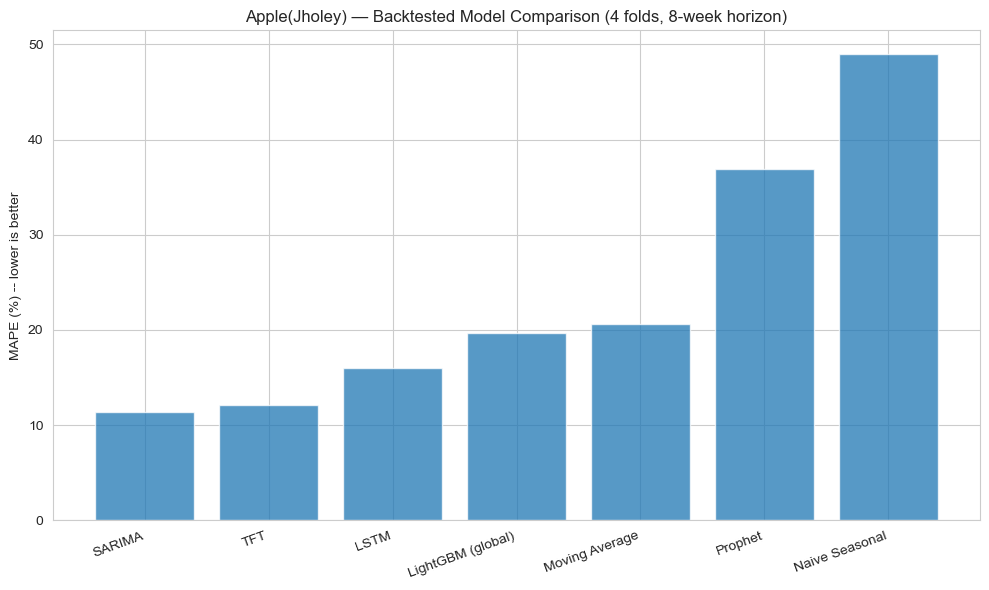

Best candidate model (SARIMA/Prophet/LSTM/TFT): SARIMA (MAPE 11.4%)
Strongest baseline: Moving Average (MAPE 20.6%)
-> SARIMA beats the strongest baseline by 9.2 points (45% relative reduction in error).


In [12]:
# the deployable candidate pool is fixed to {SARIMA, Prophet, LSTM, TFT} -- baselines exist only as
# a bar to clear, not as candidates themselves (picking "Moving Average" as the "best model" would
# defeat the point of comparing against a baseline at all)
CANDIDATE_MODELS = [m for m, present in [("SARIMA", HAS_STATSMODELS), ("Prophet", HAS_PROPHET),
                                          ("LSTM", HAS_NEURALFORECAST), ("TFT", HAS_NEURALFORECAST)] if present]
BASELINE_MODELS = ["Naive Seasonal", "Moving Average"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(comparison["model"], comparison["mape"], color="tab:blue", alpha=0.75)
ax.set_ylabel("MAPE (%) -- lower is better")
ax.set_title(f"{DEMO_COMMODITY} — Backtested Model Comparison ({N_ORIGINS} folds, {HORIZON_WEEKS}-week horizon)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/model_comparison_{DEMO_COMMODITY.replace(' ', '_')}.png", dpi=150)
plt.show()

candidate_rows = comparison[comparison["model"].isin(CANDIDATE_MODELS)].dropna(subset=["mape"]).sort_values("mape")
baseline_rows = comparison[comparison["model"].isin(BASELINE_MODELS)].dropna(subset=["mape"]).sort_values("mape")

best_candidate = candidate_rows.iloc[0]["model"]
best_candidate_mape = candidate_rows.iloc[0]["mape"]
best_baseline = baseline_rows.iloc[0]["model"]
best_baseline_mape = baseline_rows.iloc[0]["mape"]

print(f"Best candidate model ({'/'.join(CANDIDATE_MODELS)}): {best_candidate} (MAPE {best_candidate_mape:.1f}%)")
print(f"Strongest baseline: {best_baseline} (MAPE {best_baseline_mape:.1f}%)")
if best_candidate_mape < best_baseline_mape:
    print(f"-> {best_candidate} beats the strongest baseline by {best_baseline_mape - best_candidate_mape:.1f} "
          f"points ({(1 - best_candidate_mape / best_baseline_mape) * 100:.0f}% relative reduction in error).")
else:
    print(f"-> WARNING: no candidate model beat the strongest baseline for {DEMO_COMMODITY}. This "
          "commodity's price may be close to a pure repeating seasonal pattern with little additional "
          "learnable structure, or the candidate models need tuning for it.")

## 10. Run Across Multiple Commodities

The single-commodity view above is for inspection. Running the same comparison across several commodities tells you whether one model type consistently wins, or whether the best choice varies by commodity (which would itself be a useful finding — e.g. "SARIMA wins for strongly seasonal staples, TFT wins for volatile/sparse commodities").

In [13]:
SAMPLE_SIZE = 3   # keep small for runtime -- backtesting refits every model at every fold, per commodity
sample_commodities = eligible_commodities[:SAMPLE_SIZE]

all_results = []
for c in sample_commodities:
    print(f"Backtesting {c}...")
    series_c = weekly[weekly[COMMODITY_COL] == c].set_index("Date")["avg_price"].sort_index()

    model_fns = {
        "Naive Seasonal": naive_seasonal_forecast,
        "Moving Average": moving_average_forecast,
    }
    if HAS_STATSMODELS:
        model_fns["SARIMA"] = sarima_forecast
    if HAS_PROPHET:
        model_fns["Prophet"] = prophet_forecast
    if HAS_LIGHTGBM:
        model_fns["LightGBM (global)"] = partial(lightgbm_forecast_fn, panel=weekly, target_commodity=c)
    if HAS_NEURALFORECAST:
        model_fns["LSTM"] = lstm_forecast
        model_fns["TFT"] = tft_forecast

    for name, fn in model_fns.items():
        fold_df = backtest_single_series_model(series_c, fn)
        all_results.append({
            "Commodity": c, "model": name,
            "mae": fold_df["mae"].mean(), "rmse": fold_df["rmse"].mean(), "mape": fold_df["mape"].mean(),
        })

all_results_df = pd.DataFrame(all_results)
all_results_df.to_csv(f"{OUTPUT_DIR}/backtest_all_commodities.csv", index=False)
all_results_df.pivot(index="Commodity", columns="model", values="mape").round(1)

Backtesting Apple(Jholey)...


c:\Users\ASUS\anaconda3\envs\vfm_agri_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
22:36:38 - cmdstanpy - INFO - Chain [1] start processing
22:36:38 - cmdstanpy - INFO - Chain [1] done processing
22:36:38 - cmdstanpy - INFO - Chain [1] start processing
22:36:38 - cmdstanpy - INFO - Chain [1] done processing
22:36:38 - cmdstanpy - INFO - Chain [1] start processing
22:36:39 - cmdstanpy - INFO - Chain [1] done processing
22:36:39 - cmdstanpy - INFO - Chain [1] start processing
22:36:39 - cmdstanpy - INFO - Chain [1] done processing
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList  

Backtesting Arum...


22:39:05 - cmdstanpy - INFO - Chain [1] start processing
22:39:05 - cmdstanpy - INFO - Chain [1] done processing
22:39:05 - cmdstanpy - INFO - Chain [1] start processing
22:39:06 - cmdstanpy - INFO - Chain [1] done processing
22:39:06 - cmdstanpy - INFO - Chain [1] start processing
22:39:06 - cmdstanpy - INFO - Chain [1] done processing
22:39:06 - cmdstanpy - INFO - Chain [1] start processing
22:39:06 - cmdstanpy - INFO - Chain [1] done processing
Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | t

Backtesting Asparagus...


c:\Users\ASUS\anaconda3\envs\vfm_agri_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\ASUS\anaconda3\envs\vfm_agri_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
22:41:20 - cmdstanpy - INFO - Chain [1] start processing
22:41:20 - cmdstanpy - INFO - Chain [1] done processing
22:41:21 - cmdstanpy - INFO - Chain [1] start processing
22:41:21 - cmdstanpy - INFO - Chain [1] done processing
22:41:21 - cmdstanpy - INFO - Chain [1] start processing
22:41:21 - cmdstanpy - INFO - Chain [1] done processing
22:41:22 - cmdstanpy - INFO - Chain [1] start processing
22:41:22 - cmdstanpy - INFO - Chain [1] done processing
Seed set to 42
GPU available: False, used: False
TPU available: 

model,LSTM,LightGBM (global),Moving Average,Naive Seasonal,Prophet,SARIMA,TFT
Commodity,,,,,,,
Apple(Jholey),16.0,19.7,20.6,49.0,37.0,11.4,12.1
Arum,15.9,11.8,15.0,12.2,16.0,10.0,19.9
Asparagus,29.0,30.0,39.0,30.3,20.3,208.7,23.6


In [14]:
overall_mape = all_results_df.groupby("model")["mape"].mean().sort_values()
print("Average evaluation metrics across all backtested commodities (lower is better):")
overall_metrics = (all_results_df.groupby("model")[["mae", "rmse", "mape"]]
                   .mean()
                   .sort_values("mape"))
display(overall_metrics.round(2))

print("Per-commodity MAPE results:")
display(all_results_df.pivot(index="Commodity", columns="model", values="mape").round(2))

candidate_ranking = overall_mape[overall_mape.index.isin(CANDIDATE_MODELS)].dropna()
baseline_ranking = overall_mape[overall_mape.index.isin(BASELINE_MODELS)].dropna()

overall_best_candidate = candidate_ranking.index[0]
overall_best_baseline = baseline_ranking.index[0]

print(f"\nBest candidate model overall: {overall_best_candidate} (MAPE {candidate_ranking.iloc[0]:.1f}%)")
print(f"Strongest baseline overall: {overall_best_baseline} (MAPE {baseline_ranking.iloc[0]:.1f}%)")
if candidate_ranking.iloc[0] < baseline_ranking.iloc[0]:
    print(f"-> {overall_best_candidate} beats the strongest baseline on average across the sample.")
else:
    print("-> WARNING: no candidate model beats the strongest baseline on average across this sample -- "
          "see the per-commodity table above before deploying anything.")

Average evaluation metrics across all backtested commodities (lower is better):


,mae,rmse,mape
model,,,
TFT,43.26,53.33,18.55
LSTM,54.41,65.81,20.31
LightGBM (global),46.85,51.43,20.51
Prophet,40.77,47.18,24.42
Moving Average,57.48,61.36,24.90
Naive Seasonal,65.35,70.52,30.49
SARIMA,326.80,332.30,76.70


Per-commodity MAPE results:


model,LSTM,LightGBM (global),Moving Average,Naive Seasonal,Prophet,SARIMA,TFT
Commodity,,,,,,,
Apple(Jholey),16.00,19.73,20.62,49.02,36.95,11.42,12.14
Arum,15.89,11.81,15.04,12.19,16.04,9.99,19.93
Asparagus,29.04,29.98,39.04,30.25,20.25,208.67,23.56



Best candidate model overall: TFT (MAPE 18.5%)
Strongest baseline overall: Moving Average (MAPE 24.9%)
-> TFT beats the strongest baseline on average across the sample.


## 11. Final Forecast — Best Model, Full Future Horizon

Generating final forecast using: TFT
Confirmed: TFT beats the strongest baseline (Moving Average) on average across the sample (18.5% vs 24.9% MAPE).


Seed set to 42


GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name                    | Type                     | Params | Mode 
-----------------------------------------------------------------------------
0 | loss                    | MAE                      | 0      | train
1 | hist_cat_embeddings     | ModuleList               | 0      | train
2 | futr_cat_embeddings     | ModuleList               | 0      | train
3 | stat_cat_embeddings     | ModuleList               | 0      | train
4 | padder_train            | ConstantPad1d            | 0      | train
5 | scaler                  | TemporalNorm             | 0      | train
6 | embedding               | TFTEmbedding             | 320    | train
7 | temporal_encoder        | TemporalCovariateEncoder | 61.9 K | train
8 | temporal_fusion_decoder | TemporalFusionDecoder    | 17.0 K | train
9 | output_adapter          | Linear                   | 33     | train
------------------------------------------------------

Forward forecast values:


,Date,Forecast,Moving average baseline
0,2021-05-23,259.130005,212.68
1,2021-05-30,259.779999,212.68
2,2021-06-06,250.899994,212.68
3,2021-06-13,247.029999,212.68
4,2021-06-20,243.300003,212.68
5,2021-06-27,240.750000,212.68
6,2021-07-04,227.820007,212.68
7,2021-07-11,233.389999,212.68
8,2021-07-18,238.529999,212.68
9,2021-07-25,241.839996,212.68


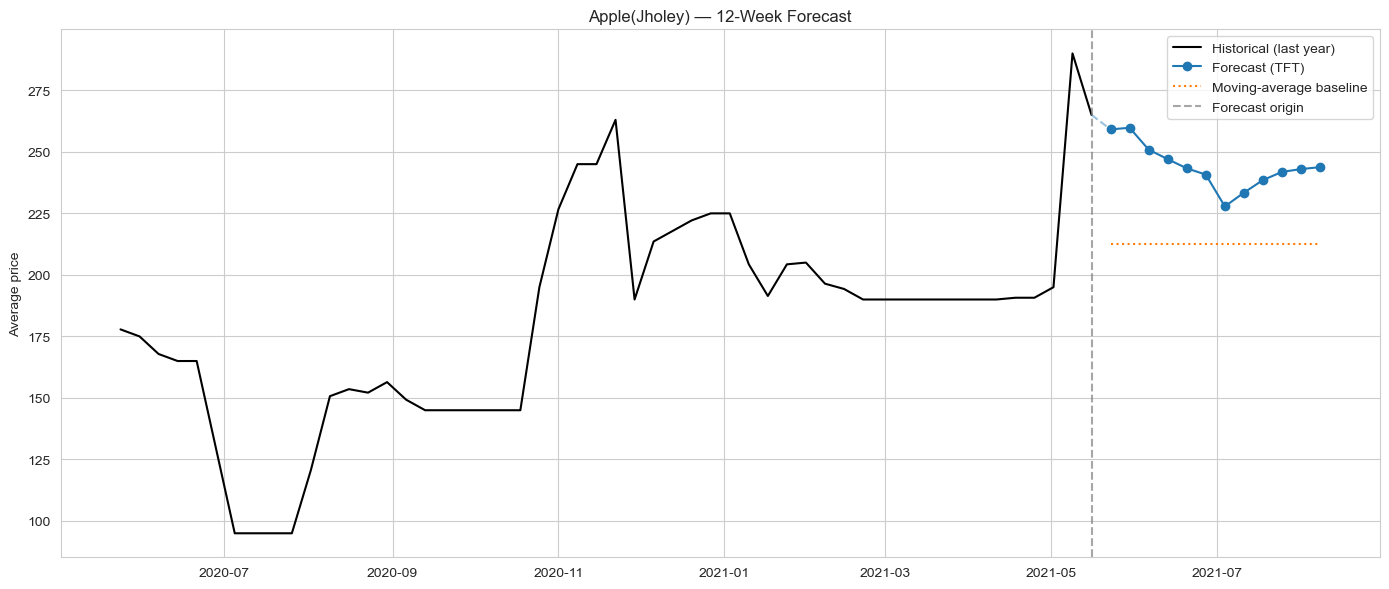

In [15]:
# --- Final-forecast-only improvements over the (deliberately shrunk) backtest config ---
# 1) bigger training budget (NF_FINAL_MAX_STEPS/NF_FINAL_INPUT_SIZE) since this only runs once
# 2) global training across every commodity in `weekly`, not just the target series -- same
#    rationale as the LightGBM section: a short/volatile series borrows structure from the rest
# 3) the same calendar exogenous features used in the backtest (_add_calendar_exog)
def _neuralforecast_global_forecast(model_cls, panel, target_commodity, horizon, **model_kwargs):
    if not HAS_NEURALFORECAST:
        raise RuntimeError("neuralforecast not installed")
    panel_df = _add_calendar_exog(
        panel[[COMMODITY_COL, "Date", "avg_price"]]
            .rename(columns={COMMODITY_COL: "unique_id", "Date": "ds", "avg_price": "y"})
    )
    model = model_cls(h=horizon, input_size=NF_FINAL_INPUT_SIZE, max_steps=NF_FINAL_MAX_STEPS,
                       hist_exog_list=NF_EXOG_COLS, futr_exog_list=NF_EXOG_COLS,
                       start_padding_enabled=True,  # some commodities have far fewer than NF_FINAL_INPUT_SIZE weeks
                       enable_progress_bar=False, accelerator="cpu", logger=False,
                       enable_checkpointing=False, val_check_steps=10_000,
                       early_stop_patience_steps=-1, random_seed=42, **model_kwargs)
    nf = NeuralForecast(models=[model], freq="W")
    nf.fit(df=panel_df)
    futr_df = _add_calendar_exog(nf.make_future_dataframe())
    forecast = nf.predict(futr_df=futr_df)
    target_forecast = forecast[forecast["unique_id"] == target_commodity].sort_values("ds")
    return target_forecast[model_cls.__name__].values


def lstm_forecast_final(panel, target_commodity, horizon):
    return _neuralforecast_global_forecast(LSTM, panel, target_commodity, horizon)


def tft_forecast_final(panel, target_commodity, horizon):
    return _neuralforecast_global_forecast(TFT, panel, target_commodity, horizon,
                                            hidden_size=NF_FINAL_TFT_HIDDEN_SIZE, n_head=NF_FINAL_TFT_N_HEAD)


# the deployed model must come from {SARIMA, Prophet, LSTM, TFT} -- never a baseline -- and we check
# it against the strongest baseline before calling it "final" rather than assuming a win
FINAL_MODEL = candidate_ranking.index[0]   # override manually if you prefer a different candidate for interpretability
FINAL_HORIZON_WEEKS = 12

beats_baseline = candidate_ranking.iloc[0] < baseline_ranking.iloc[0]
print(f"Generating final forecast using: {FINAL_MODEL}")
if beats_baseline:
    print(f"Confirmed: {FINAL_MODEL} beats the strongest baseline ({overall_best_baseline}) on average "
          f"across the sample ({candidate_ranking.iloc[0]:.1f}% vs {baseline_ranking.iloc[0]:.1f}% MAPE).")
else:
    print(f"CAVEAT: {FINAL_MODEL} is only the best of the candidate models -- it did NOT beat the "
          f"strongest baseline ({overall_best_baseline}, {baseline_ranking.iloc[0]:.1f}% MAPE) on this "
          "sample. Treat this forecast as illustrative, not deployment-ready, until that changes.")

full_series = demo_series  # change target commodity here if needed
last_date = full_series.index[-1]
future_dates = pd.date_range(last_date + pd.Timedelta(weeks=1), periods=FINAL_HORIZON_WEEKS, freq="W")

if FINAL_MODEL == "SARIMA" and HAS_STATSMODELS:
    final_pred = sarima_forecast(full_series, FINAL_HORIZON_WEEKS)
elif FINAL_MODEL == "Prophet" and HAS_PROPHET:
    final_pred = prophet_forecast(full_series, FINAL_HORIZON_WEEKS)
elif FINAL_MODEL == "LSTM" and HAS_NEURALFORECAST:
    final_pred = lstm_forecast_final(weekly, DEMO_COMMODITY, FINAL_HORIZON_WEEKS)
elif FINAL_MODEL == "TFT" and HAS_NEURALFORECAST:
    final_pred = tft_forecast_final(weekly, DEMO_COMMODITY, FINAL_HORIZON_WEEKS)
else:
    raise RuntimeError(f"No forecast implementation wired up for FINAL_MODEL={FINAL_MODEL!r}")

# 4) a multi-step forecast that's nearly flat relative to how volatile the series actually is is a red
# flag -- usually means the model under-fit (too little data/capacity/training) and hedged toward a
# central estimate instead of reacting to trend or seasonality, not a genuine "prices will hold steady"
# prediction. Mirrors the SARIMA-explosion guard above: surface the failure mode instead of hiding it.
trailing_std = full_series.iloc[-52:].std()
forecast_std = np.std(final_pred)
if trailing_std > 0 and forecast_std < 0.15 * trailing_std:
    print(f"CAUTION: the forecast is nearly flat (std={forecast_std:.1f}) relative to the trailing "
          f"52-week volatility (std={trailing_std:.1f}) -- treat this as a sign the model under-fit, "
          "not as a genuine 'prices will hold steady' prediction.")

baseline_pred = moving_average_forecast(full_series, FINAL_HORIZON_WEEKS)
forecast_table = pd.DataFrame({
    "Date": future_dates,
    "Forecast": final_pred,
    "Moving average baseline": baseline_pred,
})
print("Forward forecast values:")
display(forecast_table.round(2))

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(full_series.index[-52:], full_series.values[-52:], label="Historical (last year)", color="black")
ax.plot([last_date, future_dates[0]], [full_series.iloc[-1], final_pred[0]],
        color="tab:blue", alpha=0.45, linestyle="--")
ax.plot(future_dates, final_pred, label=f"Forecast ({FINAL_MODEL})", color="tab:blue", marker="o")
ax.plot(future_dates, baseline_pred, label="Moving-average baseline", color="tab:orange", linestyle=":")
ax.axvline(last_date, color="gray", linestyle="--", alpha=0.7, label="Forecast origin")
ax.set_ylabel("Average price")
ax.set_title(f"{DEMO_COMMODITY} — {FINAL_HORIZON_WEEKS}-Week Forecast")
ax.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/final_forecast_{DEMO_COMMODITY.replace(' ', '_')}.png", dpi=150)
plt.show()

## Reading the Final Forecast Graph

The historical line shows the last 52 observed weekly prices; the forecast begins at the dashed forecast-origin line. A sharp difference between the last observed price and the first forecast is not automatically an error: the model estimates the expected future level from the full history rather than simply extending the latest spike.

A forecast that comes out **nearly flat relative to how volatile the series actually was**, especially one that lands close to the moving-average baseline, is the signature of an under-fit deep model hedging toward a central estimate rather than genuinely learning trend or seasonality. The cell above checks for exactly this automatically (comparing the forecast's std-dev to the trailing 52-week std-dev) and prints a `CAUTION` line when it happens — read that line first before trusting the shape of the chart.

If a caution fires, the levers already applied to make the final fit better than the backtest's deliberately shrunk config are, in order of impact:
1. **A bigger training budget** (`NF_FINAL_MAX_STEPS`, `NF_FINAL_INPUT_SIZE`) than the backtest uses, since this fit only runs once.
2. **Global training across every commodity** in `weekly` (`lstm_forecast_final` / `tft_forecast_final`), the same trick the LightGBM section already uses, so the model isn't learning from one ~300-row series in isolation.
3. **Explicit calendar exogenous features** (`month`, `weekofyear`, via `NF_EXOG_COLS`) fed as both history and known-future inputs, so seasonality doesn't have to be inferred from the raw sequence alone.

If the caution still fires after all three, the remaining lever is tuning (`NF_FINAL_MAX_STEPS`/`NF_FINAL_TFT_HIDDEN_SIZE` further up) with proper rolling validation, plus genuinely new signal the model doesn't have yet — weather, festivals, supply/arrivals data — and plotting prediction intervals rather than a single point forecast. Either way, treat this forecast as a decision *input*, not a standalone answer: it should only be preferred for deployment when it consistently beats the seasonal and moving-average baselines across commodities and folds (Sections 9–10), using MAE/RMSE alongside MAPE.

## 12. Summary & Caveats

Outputs in `./forecasting_outputs/`:
- `model_comparison_<commodity>.csv` / `.png` — single-commodity backtest comparison
- `backtest_all_commodities.csv` — MAPE per model per commodity across the sample
- `final_forecast_<commodity>.png` — forward-looking forecast from the winning model

**How the final model is chosen:** the deployable candidate pool is `{SARIMA, Prophet, LSTM, TFT}` only — Naive Seasonal and Moving Average are baselines to clear, not candidates, and LightGBM is kept purely as a reference point (it's a different kind of model — global across commodities — and isn't part of the "final" decision). Sections 9 and 11 explicitly report whether the winning candidate actually beats the strongest baseline, both for the single demo commodity and on average across the sample, rather than silently assuming a win.

**Honest caveats to include in any report:**
- MAPE can be misleading for commodities with prices near zero or with occasional very cheap weeks (division blows up the error) — cross-check with MAE/RMSE, not MAPE alone.
- SARIMA forecasts are clipped to a generous multiple of the training range to guard against the occasional non-converged fit producing an explosive (e.g. 10^15 MAPE) forecast — watch for commodities where this clipping is doing real work, since it's masking a fit that should probably use a different `order`/`seasonal_order` for that series.
- The LightGBM global model's recursive multi-step forecasting compounds error over the horizon — its short-horizon (1-2 week) accuracy is typically more trustworthy than its 8-week-out accuracy.
- LSTM and TFT are deliberately small (`NF_MAX_STEPS`, `NF_TFT_HIDDEN_SIZE`) **during the backtest** to keep its runtime tractable on CPU — this is fine for *selecting* which model family wins, but the winning family's Section 9/10 numbers understate what it can actually do. Section 11's final forecast compensates with a bigger training budget, global (cross-commodity) training, and explicit calendar exogenous features (`NF_FINAL_*` / `NF_EXOG_COLS`), plus an automatic check that flags a forecast that came out suspiciously flat relative to the series' own volatility.
- SARIMA, Prophet, LSTM, and TFT are all refit from scratch at every backtest fold, which is correct practice but means this notebook's runtime scales with `N_ORIGINS x SAMPLE_SIZE` — reduce either if this is too slow on your machine (TFT is the slowest, even after shrinking it).
- All models here are trained on **weekly-resampled** data — if your actual business decision needs daily precision, this notebook establishes which model family wins, then that model can be refit at daily granularity separately.
- None of these models know about one-off future shocks (policy changes, extreme weather) with no historical precedent — same caveat as the Monte Carlo simulation notebook.